In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
df = pd.read_csv('data/hotel-booking.csv')
df.head()

,booking_id,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,total_guests,country,previous_cancellations,reserved_room_type,booking_changes,company,adr,total_of_special_requests,is_canceled
0,48878,71,4,14,1,0,2,2,0.0,0,2,AUT,0,1,0,NaN,87.3,0,Y
1,91854,192,6,26,24,0,2,1,0.0,0,1,PRT,0,1,0,NaN,95.0,0,N
2,115699,18,7,27,8,1,1,2,0.0,0,2,PRT,0,5,2,NaN,195.0,2,N
3,100515,37,10,44,27,0,2,2,0.0,0,2,JPN,0,1,1,NaN,109.0,1,N
4,67535,219,5,18,4,0,3,2,0.0,0,2,GBR,0,4,0,NaN,130.5,3,Y


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16611 entries, 0 to 16610
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   booking_id                 16611 non-null  int64  
 1   lead_time                  16611 non-null  int64  
 2   arrival_date_month         16611 non-null  int64  
 3   arrival_date_week_number   16611 non-null  int64  
 4   arrival_date_day_of_month  16611 non-null  int64  
 5   stays_in_weekend_nights    16611 non-null  int64  
 6   stays_in_week_nights       16611 non-null  int64  
 7   adults                     16611 non-null  int64  
 8   children                   16607 non-null  float64
 9   babies                     16611 non-null  int64  
 10  total_guests               16611 non-null  int64  
 11  country                    16606 non-null  object 
 12  previous_cancellations     16611 non-null  int64  
 13  reserved_room_type         16411 non-null  obj

The dataset contains 16,611 booking records and 19 variables. The initial inspection was used to identify variable data types and missing values before any preprocessing was performed.

In [62]:
cancel_proportions = df["is_canceled"].value_counts(normalize=True) * 100
cancel_counts = df["is_canceled"].value_counts()

print("Counts:")
print(cancel_counts)

print("\nProportions (%):")
print(cancel_proportions)

Counts:
is_canceled
N    9680
Y    6931
Name: count, dtype: int64

Proportions (%):
is_canceled
N    58.274637
Y    41.725363
Name: proportion, dtype: float64


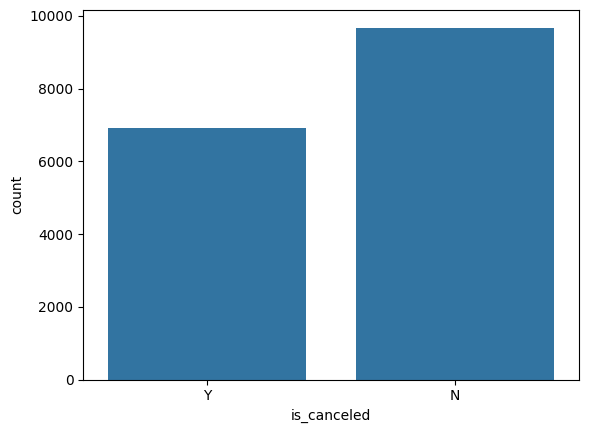

In [63]:
# distribution plot for the categorical column of "Type"
g = sns.countplot(data = df, x = 'is_canceled')
plt.show()

#### Q1
Of the 16,611 bookings, 9,680 (58.27%) were not cancelled and 6,931 (41.73%) were cancelled. The target variable is therefore slightly imbalanced towards non-cancelled bookings, although both classes are well represented.

In [64]:
# Missing values 
missing_values = df.isnull().sum()
missing_values

booking_id                       0
lead_time                        0
arrival_date_month               0
arrival_date_week_number         0
arrival_date_day_of_month        0
stays_in_weekend_nights          0
stays_in_week_nights             0
adults                           0
children                         4
babies                           0
total_guests                     0
country                          5
previous_cancellations           0
reserved_room_type             200
booking_changes                  0
company                      15867
adr                             53
total_of_special_requests        0
is_canceled                      0
dtype: int64

* children -> 4 missing values (datatype is float, but it needs to be int)
* country -> 5 missing values (datatype is categorical dont use numerical imputation)
* reserved_room_type -> 200 missing values (datatype is categorical dont use numerical imputation)
* company -> missing 15867 values (about 95.5% missing)
* adr -> missing 53 values
* Another thing to look into is if total = adults + children if so we can remove total?

In [65]:
duplicate_count = df.duplicated().sum()
duplicate_count

np.int64(0)

No completely duplicated records were found in the dataset, so no duplicate removal was required.

In [66]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
booking_id,16611.0,79798.960869,22902.227887,40061.0,60097.5,79713.0,99622.0,119387.0
lead_time,16611.0,109.948167,111.545559,-1.0,23.0,74.0,163.0,629.0
arrival_date_month,16611.0,6.572572,3.041884,1.0,4.0,7.0,9.0,12.0
arrival_date_week_number,16611.0,27.248992,13.410847,1.0,17.0,27.0,38.0,53.0
arrival_date_day_of_month,16611.0,15.807417,8.769745,1.0,8.0,16.0,24.0,31.0
stays_in_weekend_nights,16611.0,0.795437,0.882872,0.0,0.0,1.0,2.0,16.0
stays_in_week_nights,16611.0,2.178556,1.461783,0.0,1.0,2.0,3.0,41.0
adults,16611.0,1.857323,0.514326,0.0,2.0,2.0,2.0,4.0
children,16607.0,0.088637,0.365593,0.0,0.0,0.0,0.0,3.0
babies,16611.0,0.004756,0.095858,0.0,0.0,0.0,0.0,9.0


The descriptive statistics were examined for values that were impossible or potentially unusual. A negative lead_time and bookings with zero total guests were considered possible data-quality problems. Large values such as long stays or high ADR were investigated but were not automatically considered errors because they could represent legitimate bookings.

| Column                    |   What we see | Why suspicious                                                                   | What to do next                                     |
| ------------------------- | ------------: | -------------------------------------------------------------------------------- | --------------------------------------------------- |
| `lead_time`               |  **min = -1** | Lead time is days between booking and arrival, so negative time appears invalid  | Find rows with `< 0`                                |
| `total_guests`            |   **min = 0** | A hotel booking with zero recorded guests is suspicious                          | Inspect these rows                                  |
| `adults`                  |   **min = 0** | Could be valid if children are present, but suspicious if total guests is also 0 | Inspect combinations                                |
| `babies`                  |   **max = 9** | Very unusual compared with Q3 = 0                                                | Investigate row(s), don't automatically remove      |
| `stays_in_weekend_nights` |  **max = 16** | Much larger than Q3 = 2                                                          | Possible legitimate long stay; investigate          |
| `stays_in_week_nights`    |  **max = 41** | Much larger than Q3 = 3                                                          | Possible legitimate long stay; investigate          |
| `adr`                     | **max = 510** | Much higher than Q3 = 126                                                        | Potential outlier, but entirely possible hotel rate |


* The clearest actual data-quality problem from this table is lead_time = -1. The assignment defines lead_time as the number of days between booking and scheduled arrival, so a negative value seems suspicious.
* total_guests = 0 is also suspicious

In [67]:
# Check if total is redundant 
calculated_guests = (
    df["adults"]
    + df["children"].fillna(0) 
    + df["babies"]
)

mismatch = df[df["total_guests"] != calculated_guests]

print("Mismatches:", len(mismatch))

Mismatches: 0


After temporarily treating the four missing `children` values as zero for comparison, `total_guests` matched `adults` + `children` + `babies` for every observation. Therefore, `total_guests` contains information already represented by the three guest-composition variables and was considered redundant. The individual variables were retained because they distinguish between `adults`, `children` and `babies`.

In [68]:
df[df['children'].isna()]

,booking_id,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,total_guests,country,previous_cancellations,reserved_room_type,booking_changes,company,adr,total_of_special_requests,is_canceled
9506,40668,1,8,32,5,0,2,2,NaN,0,2,PRT,0,2,0,NaN,12.0,1,Y
9512,41161,8,8,33,13,2,5,2,NaN,0,2,PRT,0,2,0,NaN,76.5,1,Y
10023,40601,2,8,32,3,1,0,2,NaN,0,2,PRT,0,2,0,NaN,12.0,1,Y
12082,40680,1,8,32,5,0,2,3,NaN,0,3,PRT,0,2,0,NaN,18.0,2,Y


The `children` variable contained 4 missing values. These values were replaced with 0 because the recorded `total_guests` for these observations matched `adults` + `babies`, indicating that no `children` were included in these bookings. After imputation, the variable was converted to integer type because guest counts are discrete values.

### Invalid `lead_time`

In [69]:
negative_lead_time = df[df["lead_time"] < 0]

print("Number of negative lead times:", len(negative_lead_time))
negative_lead_time

Number of negative lead times: 32


,booking_id,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,total_guests,country,previous_cancellations,reserved_room_type,booking_changes,company,adr,total_of_special_requests,is_canceled
185,86960,-1,4,15,9,2,1,2,2.0,0,4,PRT,0,6,1,NaN,NaN,0,N
334,112274,-1,5,20,19,1,2,1,0.0,0,1,GBR,0,1,0,NaN,144.00,0,N
335,61686,-1,12,52,22,2,5,2,0.0,0,2,PRT,0,4,0,NaN,70.88,1,Y
336,54352,-1,7,29,14,0,2,2,0.0,0,2,PRT,0,1,0,NaN,62.00,0,Y
337,54540,-1,7,30,19,0,4,2,0.0,0,2,PRT,0,1,0,NaN,72.25,0,Y
338,81431,-1,12,50,9,0,2,1,0.0,0,1,PRT,0,1,0,NaN,62.00,0,N
339,59829,-1,11,45,3,0,2,2,0.0,0,2,PRT,0,1,0,NaN,62.80,0,Y
340,75789,-1,9,36,5,2,2,2,0.0,0,2,PRT,1,1,0,NaN,62.00,0,Y
341,75442,-1,9,37,9,0,2,2,0.0,0,2,PRT,1,1,0,NaN,62.00,0,Y
342,92134,-1,6,27,29,0,2,3,0.0,0,3,PRT,0,1,0,NaN,146.70,2,N


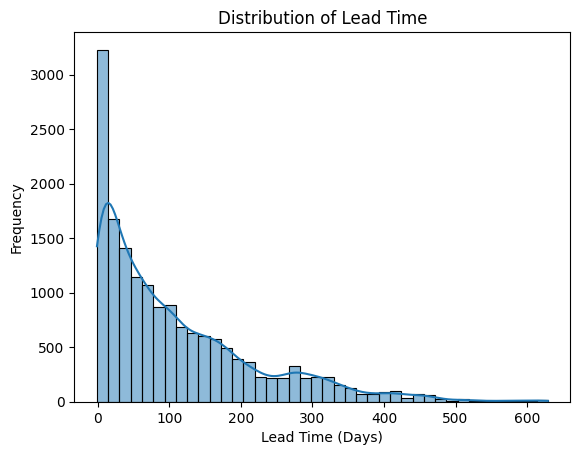

In [70]:
sns.histplot(
    data=df,
    x="lead_time",
    bins=40,
    kde=True
)

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Frequency")
plt.show()

lead_time contained 32 observations with a value of -1. Because lead time represents the number of days between booking and arrival, negative values were considered invalid. These values were treated as missing and planned for median imputation. The distribution was strongly right-skewed, making the median more robust to large lead-time values than the mean.

### Zero-guest bookings

In [71]:
zero_guests = df[(df["total_guests"] == 0)]

print("Number of bookings with zero guests:", len(zero_guests))

display(zero_guests)

Number of bookings with zero guests: 32


,booking_id,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,total_guests,country,previous_cancellations,reserved_room_type,booking_changes,company,adr,total_of_special_requests,is_canceled
421,106834,50,3,9,1,0,3,0,0.0,0,0,IRN,0,1,1,NaN,86.40,1,N
822,84199,19,2,8,14,3,5,0,0.0,0,0,GBR,0,1,1,NaN,0.00,1,N
979,64783,0,3,11,16,0,3,0,0.0,0,0,PRT,0,1,0,NaN,0.00,0,Y
1272,102130,216,11,48,22,0,1,0,0.0,0,0,PRT,0,1,2,233.0,0.00,0,N
1711,42453,1,9,37,6,2,0,0,0.0,0,0,PRT,0,1,0,NaN,0.00,0,Y
2274,102320,2,11,47,16,2,8,0,0.0,0,0,ITA,0,1,6,NaN,0.00,0,N
2275,72969,0,8,32,11,0,0,0,0.0,0,0,PRT,0,8,0,NaN,0.00,0,Y
2505,102186,19,11,48,26,4,7,0,0.0,0,0,USA,0,1,4,NaN,6.40,0,N
3052,79078,64,10,42,16,2,3,0,0.0,0,0,FRA,0,1,2,NaN,0.00,0,N
3353,101795,140,9,39,22,16,41,0,0.0,0,0,GBR,0,1,12,NaN,8.34,2,N


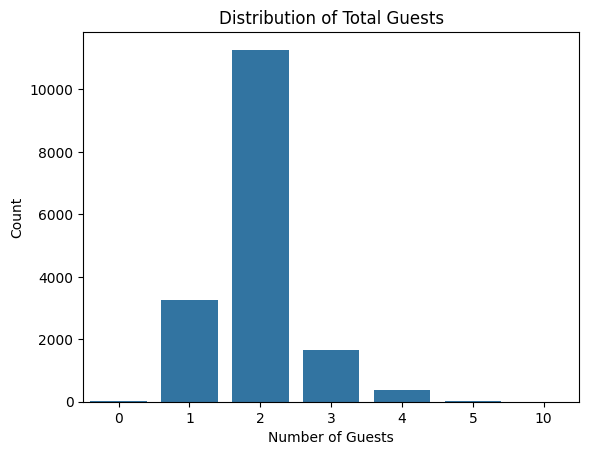

In [72]:
sns.countplot(data=df, x="total_guests")

plt.title("Distribution of Total Guests")
plt.xlabel("Number of Guests")
plt.ylabel("Count")
plt.show()

32 observations contained zero adults, zero children and zero babies, resulting in total_guests = 0. These records were considered invalid because they represented bookings with no recorded guests. As the actual number and composition of guests could not be determined reliably, the records were planned for removal rather than imputation. These records represented only approximately 0.19% of the dataset.

In [73]:
df[df["country"].isna()]

,booking_id,lead_time,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,total_guests,country,previous_cancellations,reserved_room_type,booking_changes,company,adr,total_of_special_requests,is_canceled
6220,44899,193,10,42,15,0,3,2,0.0,0,2,NaN,0,1,0,NaN,65.0,0,Y
7357,44906,193,10,42,15,0,3,2,0.0,0,2,NaN,0,1,0,NaN,65.0,0,Y
9157,65911,0,4,15,10,0,0,0,0.0,0,0,NaN,0,8,0,279.0,0.0,0,Y
12895,44902,193,10,42,15,0,3,2,0.0,0,2,NaN,0,1,0,NaN,65.0,0,Y
13785,44896,193,10,42,15,0,3,2,0.0,0,2,NaN,0,1,0,NaN,65.0,0,Y


In [74]:
print("Number of countries:", df["country"].nunique())

print(df["country"].value_counts(dropna=False).head(20))

Number of countries: 127
country
PRT    6367
FRA    1865
DEU    1294
GBR    1112
ESP     941
ITA     731
BEL     407
NLD     376
BRA     376
USA     302
CHE     275
IRL     247
AUT     192
CHN     189
SWE     162
POL     142
ISR     136
NOR     113
CN      112
RUS      94
Name: count, dtype: int64


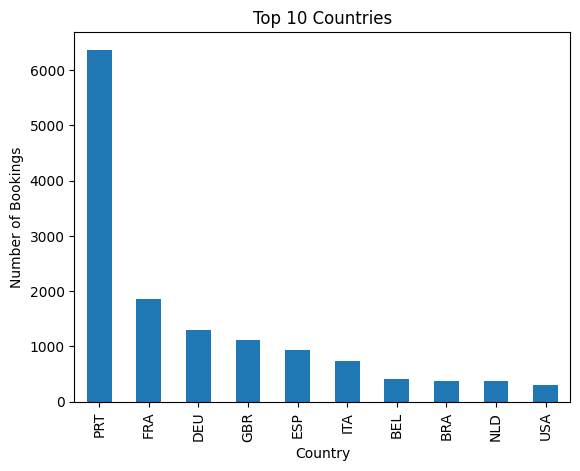

In [75]:
df["country"].value_counts().head(10).plot(
    kind="bar"
)

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Number of Bookings")
plt.show()

country contains 5 missing values. The distribution is highly imbalanced, with PRT being the dominant category. The missing values should not automatically be assigned to PRT because there is insufficient evidence that the missing observations belong to the most frequent country. An explicit `unknown` category can be considered to preserve these records without introducing an assumed country.

### Looking into `reserved_room_type`

In [76]:
room_counts = df["reserved_room_type"].value_counts(dropna=False)
room_counts

reserved_room_type
1      12920
4       2505
5        337
6        332
2        215
NaN      200
7         90
?          5
3          5
8          2
Name: count, dtype: int64

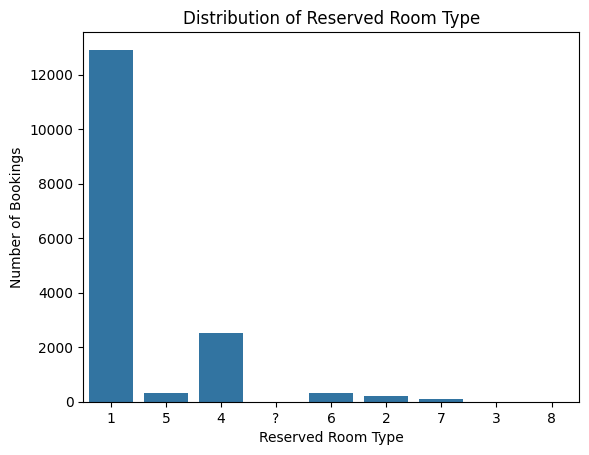

In [77]:
sns.countplot(
    data=df,
    x="reserved_room_type"
)

plt.title("Distribution of Reserved Room Type")
plt.xlabel("Reserved Room Type")
plt.ylabel("Number of Bookings")
plt.show()

In [78]:
missing_room = df["reserved_room_type"].isna().sum()
missing_room

np.int64(200)

In [79]:
print("NaN values:", df["reserved_room_type"].isna().sum())
print("'?' values:", (df["reserved_room_type"] == "?").sum())

NaN values: 200
'?' values: 5


Reserved Room Type: The reserved_room_type variable contained 200 missing (NaN) values and 5 values represented as "?". The "?" values were considered another representation of unknown/missing room type. Both were therefore combined into a new `unknown` category. This preserves the observations without assuming that the missing values belong to the most frequent room type.

### Looking into `company`

In [80]:
company_missing = df["company"].isna().sum()
company_missing_pct = df["company"].isna().mean() * 100

print("Missing values:", company_missing)
print(f"Missing percentage: {company_missing_pct:.2f}%")

Missing values: 15867
Missing percentage: 95.52%


`company` contained 15,867 missing observations, representing approximately 95.5% of the dataset. Because very little information was available for this variable, meaningful imputation was not considered reliable. The variable was therefore selected for removal.

### Looking into `adr`

In [81]:
print(df["adr"].describe())

count    16558.000000
mean       105.272994
std         39.343559
min          0.000000
25%         79.200000
50%        100.000000
75%        126.000000
max        510.000000
Name: adr, dtype: float64


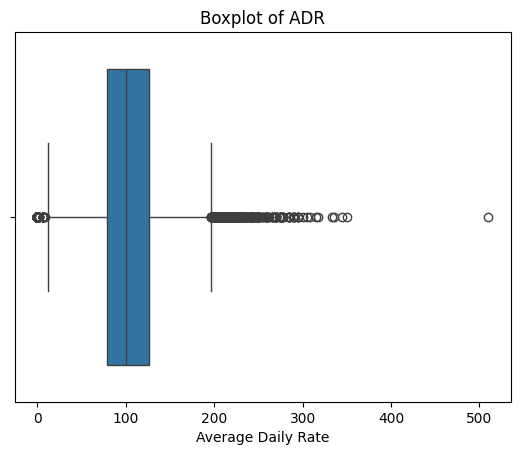

In [82]:
sns.boxplot(x=df["adr"])

plt.title("Boxplot of ADR")
plt.xlabel("Average Daily Rate")
plt.show()

`adr` contained 53 missing observations. Because ADR is numerical and its distribution contains relatively high values, median imputation was selected. The median is less affected by extreme values than the mean and allows the affected observations to be retained.

### Summary of preprocessing decisions

| Issue                    | Variable             | Decision                                     |
| ------------------------ | -------------------- | -------------------------------------------- |
| Identifier               | `booking_id`         | Remove                                       |
| Invalid value            | `lead_time = -1`     | Replace with missing, then median imputation |
| Missing values           | `children`           | Replace with 0 based on guest totals         |
| Missing values           | `country`            | Flag with `Unknown`                          |
| Missing/invalid category | `reserved_room_type` | Flag `NaN` and `?` with `Unknown`            |
| Excessive missing values | `company`            | Remove                                       |
| Missing values           | `adr`                | Median imputation                            |
| Redundant variable       | `total_guests`       | Remove                                       |
| Invalid records          | Zero-guest bookings  | Remove rows                                  |


### Apply preprocessing

In [83]:
clean_df = df.copy()

In [84]:
# Remove rows with total_guests == 0
clean_df = clean_df[clean_df["total_guests"] != 0].copy()
clean_df.reset_index(drop=True, inplace=True)

# Convert invalid negative lead_time values to NaN, then replace with median. Also convert the data type back to int 
clean_df.loc[clean_df["lead_time"] < 0, "lead_time"] = np.nan
clean_df["lead_time"] = (clean_df["lead_time"].fillna(clean_df["lead_time"].median()).astype(int))

# Replace the four missing child counts with 0 and convert to integer
clean_df["children"] = clean_df["children"].fillna(0).astype(int)

# Replace missing categorical values with an Unknown category
clean_df["country"] = clean_df["country"].fillna("Unknown")

clean_df["reserved_room_type"] = (
    clean_df["reserved_room_type"]
    .replace("?", "Unknown")
    .fillna("Unknown")
)

# Replace missing ADR values with the median
clean_df["adr"] = clean_df["adr"].fillna(
    clean_df["adr"].median()
)

# Remove unnecessary/redundant variables
columns_to_remove = [
    "booking_id",
    "company",
    "total_guests"
]

clean_df = clean_df.drop(columns=columns_to_remove)

### Validation of the data after preprocessing 

In [85]:
print("Cleaned dataset shape:", clean_df.shape)

print(clean_df.isnull().sum())

print("\nNegative lead times:")
print((clean_df["lead_time"] < 0).sum())

print("\nData types:")
print(clean_df.dtypes)

Cleaned dataset shape: (16579, 16)
lead_time                    0
arrival_date_month           0
arrival_date_week_number     0
arrival_date_day_of_month    0
stays_in_weekend_nights      0
stays_in_week_nights         0
adults                       0
children                     0
babies                       0
country                      0
previous_cancellations       0
reserved_room_type           0
booking_changes              0
adr                          0
total_of_special_requests    0
is_canceled                  0
dtype: int64

Negative lead times:
0

Data types:
lead_time                      int64
arrival_date_month             int64
arrival_date_week_number       int64
arrival_date_day_of_month      int64
stays_in_weekend_nights        int64
stays_in_week_nights           int64
adults                         int64
children                       int64
babies                         int64
country                       object
previous_cancellations         int64
reserved_roo

In [86]:
clean_df["lead_time"]

0         71
1        192
2         18
3         37
4        219
        ... 
16574    420
16575    124
16576      3
16577     17
16578     56
Name: lead_time, Length: 16579, dtype: int64

In [87]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16579 entries, 0 to 16578
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   lead_time                  16579 non-null  int64  
 1   arrival_date_month         16579 non-null  int64  
 2   arrival_date_week_number   16579 non-null  int64  
 3   arrival_date_day_of_month  16579 non-null  int64  
 4   stays_in_weekend_nights    16579 non-null  int64  
 5   stays_in_week_nights       16579 non-null  int64  
 6   adults                     16579 non-null  int64  
 7   children                   16579 non-null  int64  
 8   babies                     16579 non-null  int64  
 9   country                    16579 non-null  object 
 10  previous_cancellations     16579 non-null  int64  
 11  reserved_room_type         16579 non-null  object 
 12  booking_changes            16579 non-null  int64  
 13  adr                        16579 non-null  flo

In [88]:
clean_df["country"].unique()

array(['AUT', 'PRT', 'JPN', 'GBR', 'ESP', 'FRA', 'DEU', 'SWE', 'CHE',
       'ROU', 'ITA', 'CHN', 'SGP', 'KOR', 'IRL', 'KWT', 'CN', 'US', 'NLD',
       'CHL', 'FIN', 'BEL', 'BRA', 'AUS', 'AGO', 'SVK', 'NOR', 'ZAF',
       'POL', 'DZA', 'GRC', 'TUR', 'NZL', 'THA', 'ISR', 'HUN', 'BGR',
       'DNK', 'LTU', 'ARG', 'USA', 'ARE', 'SLE', 'RUS', 'PAN', 'CRI',
       'BHR', 'COL', 'CZE', 'MKD', 'EST', 'SVN', 'ISL', 'CYP', 'IND',
       'MEX', 'PHL', 'IRN', 'TWN', 'TUN', 'LUX', 'ALB', 'LBN', 'MOZ',
       'UKR', 'VEN', 'BRB', 'MAR', 'MLT', 'PER', 'CIV', 'HRV', 'GIB',
       'AND', 'GTM', 'EGY', 'NGA', 'BIH', 'CPV', 'AZE', 'ECU', 'URY',
       'SRB', 'BGD', 'SEN', 'JOR', 'LIE', 'JAM', 'SAU', 'TJK', 'TMP',
       'MAC', 'OMN', 'MNE', 'MYS', 'PRY', 'IDN', 'Unknown', 'IMN', 'KNA',
       'IRQ', 'HKG', 'CUB', 'KAZ', 'NIC', 'GNB', 'DMA', 'MUS', 'PAK',
       'MRT', 'TZA', 'GUY', 'STP', 'DOM', 'COM', 'QAT', 'BLR', 'GHA',
       'LVA', 'ASM', 'LBY', 'KHM', 'SYR', 'GLP', 'BEN', 'ARM', 'NCL',
       'KEN

In [89]:
clean_df["reserved_room_type"].unique()

array(['1', '5', '4', 'Unknown', '6', '2', '7', '3'], dtype=object)

### Save it

In [90]:
clean_df.to_csv("data/clean_data.csv", index=False)

In [91]:
files = {
    "clean_group_data": "data/clean_group_data.csv",
    "clean_test_A": "data/clean_test_A.csv",
    "clean_test_B": "data/clean_test_B.csv",
    "clean_test_C": "data/clean_test_C.csv"
}

summary = []

for name, path in files.items():
    data = pd.read_csv(path)

    proportions = data["is_canceled"].value_counts(normalize=True) * 100

    summary.append({
        "Dataset": name,
        "Observations": len(data),
        "Cancelled (%)": proportions.get("Y", 0),
        "Not Cancelled (%)": proportions.get("N", 0)
    })

summary_df = pd.DataFrame(summary)

display(summary_df)

,Dataset,Observations,Cancelled (%),Not Cancelled (%)
0,clean_group_data,15086,41.773830,58.226170
1,clean_test_A,497,41.851107,58.148893
2,clean_test_B,498,41.767068,58.232932
3,clean_test_C,498,41.767068,58.232932


### Split the data into train and test

In [92]:
from sklearn.model_selection import train_test_split

group_df = pd.read_csv("data/clean_group_data.csv")

X = group_df.drop(columns=["is_canceled"])
y = group_df["is_canceled"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [94]:
print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

print("Training target distribution:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("Test target distribution:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Training observations: 12068
Test observations: 3018
Training target distribution:
is_canceled
N    58.23
Y    41.77
Name: proportion, dtype: float64
Test target distribution:
is_canceled
N    58.22
Y    41.78
Name: proportion, dtype: float64
